# GOAL: Build linear regression model

In [1]:
#import statements

#import everything!
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime, timedelta
from itertools import product
from copy import deepcopy
from PreRun import PreRun, PostRun
from sklearn.metrics import mean_absolute_error, mean_squared_error
#from statsmodels.tsa.statespace.sarimax import SARIMAX
import random
from sklearn.linear_model import LinearRegression


#path to data
read_path = "../../../../data_ds_project/parquet_cleaned_energy"
#systems
good_systems_list = [4, 10, 33, 36, 50, 51, 1199, 1204, 1283, 1284, 1289, 1332, 4902, 4903]
reader_types = ["meter", "inverter", None]
#systems_cleaned
systems_cleaned = pd.read_csv("../../../data/core/systems_cleaned.csv")


In [74]:
system_id = 4
reader_type = None

prerun = PreRun(system_id = system_id, meter_or_inverter = reader_type, path=read_path, systems_cleaned=systems_cleaned)
prerun.load_data()
prerun.fill_missing_hours()
prerun.add_energy_features_only(daily_lags = 2, remove_daily_lags_nans=True, include_last_year = True, remove_last_year_nans=True, include_day_of_year_cyclic=True, include_hour_cyclic=True)
#prerun.add_energy_features_only(include_day_of_year_cyclic=True, include_hour_cyclic=True)

prerun.add_weather_features_only()

prerun.amended_data = prerun.amended_data.dropna()
all_data = prerun.amended_data
end_days = prerun.good_days
#print(end_days)

big_train_dates, big_test_dates = end_days.iloc[:int(len(end_days)*0.8)]['date'], end_days.iloc[int(len(end_days)*0.8):]['date']
big_train_dates = pd.to_datetime(big_train_dates)
big_test_dates = pd.to_datetime(big_test_dates)
big_train_dates_set = set(big_train_dates)
big_test_dates_set = set(big_test_dates)


In [67]:
#some quick eda

big_train_data = all_data.loc[all_data['time'].dt.normalize().isin(big_train_dates_set)]

big_train_data.drop(columns=['time']).corr()


,energy,last_year,2_days_ago,month_sin,month_cos,day_of_year_sin,day_of_year_cos,hour_sin,hour_cos,cloud_cover,global_tilted_irradiance,proportion_daytime
energy,1.000000,0.689053,0.714251,0.015903,0.130254,-0.005481,0.131433,0.116266,-0.757804,-0.266544,0.761064,0.297578
last_year,0.689053,1.000000,0.687405,0.022868,0.115032,0.000585,0.118168,0.110739,-0.742856,-0.020690,0.657424,0.293161
2_days_ago,0.714251,0.687405,1.000000,0.027573,0.127258,0.005483,0.132538,0.116907,-0.754730,-0.026179,0.667110,0.296258
month_sin,0.015903,0.022868,0.027573,1.000000,-0.043216,0.975799,0.181037,-0.022465,-0.002408,0.113560,0.019154,0.024149
month_cos,0.130254,0.115032,0.127258,-0.043216,1.000000,-0.212856,0.960100,0.025335,-0.211091,-0.126541,0.087825,-0.162933
day_of_year_sin,-0.005481,0.000585,0.005483,0.975799,-0.212856,1.000000,0.011639,-0.026685,0.033730,0.131055,0.004414,0.053603
day_of_year_cos,0.131433,0.118168,0.132538,0.181037,0.960100,0.011639,1.000000,0.019927,-0.210481,-0.097693,0.090804,-0.158618
hour_sin,0.116266,0.110739,0.116907,-0.022465,0.025335,-0.026685,0.019927,1.000000,0.206033,-0.214133,-0.347797,-0.014341
hour_cos,-0.757804,-0.742856,-0.754730,-0.002408,-0.211091,0.033730,-0.210481,0.206033,1.000000,-0.052112,-0.890864,-0.325995
cloud_cover,-0.266544,-0.020690,-0.026179,0.113560,-0.126541,0.131055,-0.097693,-0.214133,-0.052112,1.000000,-0.087977,0.031962


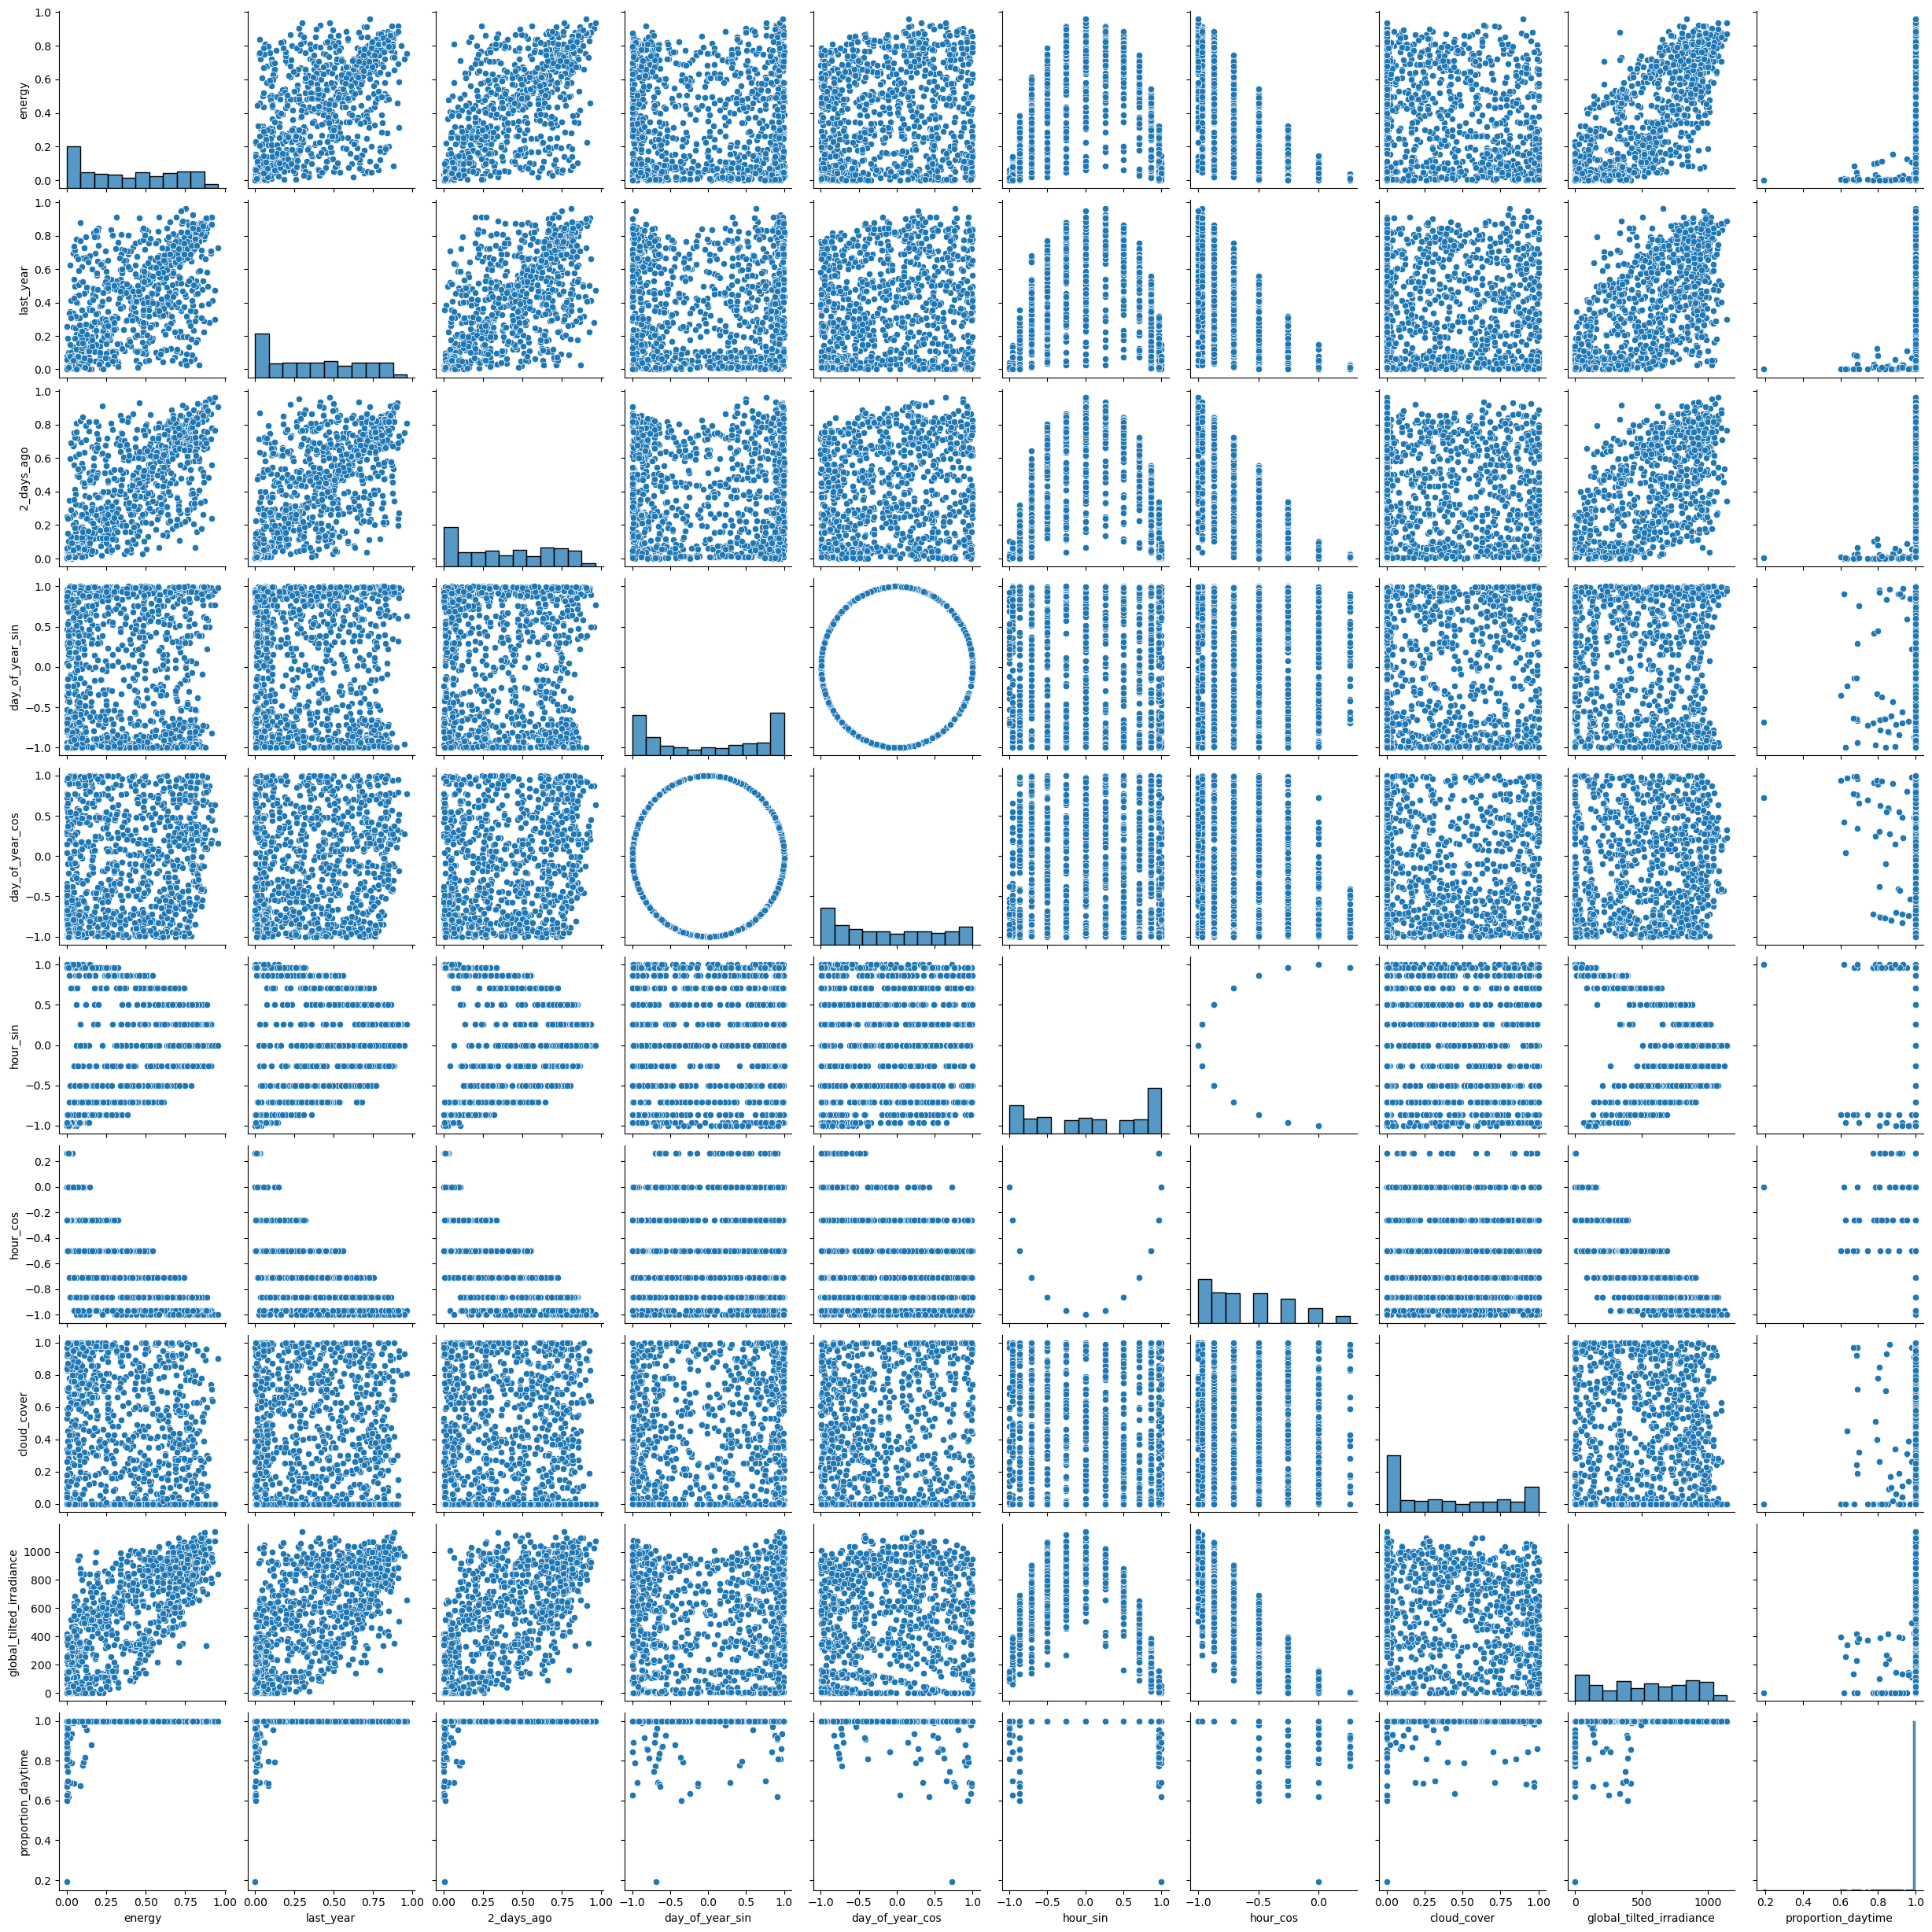

In [45]:
#some quick EDA

big_train_data = all_data.loc[all_data['time'].dt.normalize().isin(big_train_dates_set)]

big_train_data = big_train_data.loc[big_train_data['energy']>0]

df_sample = big_train_data.sample(n=1000)

sns.pairplot(df_sample)

In [ ]:
#edit this part!!!
error_list = []
testing_dates = big_test_dates_set #edit this when it comes to making folds
for pred_date in testing_dates:
    train_data = all_data.loc[(all_data['time'] < pred_date - timedelta(days=1))].reset_index(drop=True)
    
    ho_data = all_data[(all_data['time'].dt.normalize() == pd.to_datetime(pred_date))].reset_index(drop=True)
    

    linReg = LinearRegression()
    linReg.fit(train_data.drop(columns=['energy', 'time']), train_data['energy'])
    y_pred = linReg.predict(ho_data.drop(columns=['energy', 'time']))
    error = PostRun.custom_error(ho_data['energy'], y_pred)
    
    error_list.append(error)

In [76]:
print(np.mean(error_list))
error_list

0.02472067550009511


[np.float64(0.02425522508640459),
 np.float64(0.0034563300369001605),
 np.float64(0.01996281283512267),
 np.float64(0.06866777366653723),
 np.float64(0.03080417472559256),
 np.float64(0.030860141582048525),
 np.float64(0.02816679024520235),
 np.float64(0.01107058583975319),
 np.float64(0.02032368716555856),
 np.float64(0.030500122744319548),
 np.float64(0.09221266635737356),
 np.float64(0.06103456776715702),
 np.float64(0.021980036661281933),
 np.float64(0.032270734971606305),
 np.float64(0.005597607014924742),
 np.float64(0.01240285474656586),
 np.float64(0.0066720120122034255),
 np.float64(0.030543993101436743),
 np.float64(0.010466924916844178),
 np.float64(0.034559257810336294),
 np.float64(0.07128663341523019),
 np.float64(0.007497101402592256),
 np.float64(0.003485000370125958),
 np.float64(0.0119110696083906),
 np.float64(0.018147883316848055),
 np.float64(0.0036947066955870067),
 np.float64(0.0030282846062988883),
 np.float64(0.04372634994640502),
 np.float64(0.0234836354490680